<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
k-NN for Regression 
</p>

In [1]:
# Imports - core utils, data wrangling, ML, optimization, and plotting

# Standard library
import os
import pickle
import re
import time
import warnings

# Data handling
import numpy as np
import pandas as pd
from IPython.display import display

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# KNN pipeline and preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.utils.validation import check_is_fitted

# Model selection and evaluation
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
)
from sklearn.model_selection import PredefinedSplit, learning_curve

# Bayesian optimization
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

# Suppress known compatibility/noise warnings
warnings.filterwarnings("ignore", category=UserWarning, module="skopt")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Load data & folds
</p>

In [2]:
# Paths 
TRAIN_CSV = "Data_Files/train.csv"
TEST_CSV  = "Data_Files/test.csv"
FOLDS_NPY = "Data_Files/train_folds.npy"

MODELS_DIR     = "Models"
FIGURES_DIR    = "Figures"
CV_RESULTS_DIR = "CV_Results"
RESIDUALS_DIR  = "Residuals"

for directory in [MODELS_DIR, FIGURES_DIR, CV_RESULTS_DIR, RESIDUALS_DIR]:
    os.makedirs(directory, exist_ok=True)

CV_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "knn_bayes_cv_results.csv")
MODEL_PATH      = os.path.join(MODELS_DIR, "knn_final_model.pkl")

# Load time-aware train/test split and predefined train folds
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)
fold_assignments = np.load(FOLDS_NPY)

# Optional datetime parsing for reporting/saving
for df in [df_train, df_test]:
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Feature/target setup
feature_names = [
    "distance", "frequency", "c_walls", "w_walls",
    "co2", "humidity", "pm25", "pressure", "temperature", "snr"
]
target_col = "PL"

required_cols = [target_col, "device_id", *feature_names]
missing_train = [c for c in required_cols if c not in df_train.columns]
missing_test  = [c for c in required_cols if c not in df_test.columns]

if missing_train or missing_test:
    raise ValueError(
        f"Missing columns | train: {missing_train} | test: {missing_test}"
    )

if len(fold_assignments) != len(df_train):
    raise ValueError(
        f"fold_assignments length ({len(fold_assignments)}) does not match "
        f"df_train length ({len(df_train)})"
    )

# Train/test matrices
X_train_df = df_train[feature_names].copy()
X_test_df  = df_test[feature_names].copy()

X_train = X_train_df.to_numpy()
y_train = df_train[target_col].astype(float).to_numpy()

X_test = X_test_df.to_numpy()
y_test = df_test[target_col].astype(float).to_numpy()

ps = PredefinedSplit(fold_assignments)

print(f"Training samples: {len(df_train)}, Test samples: {len(df_test)}")
if "time" in df_train.columns and "time" in df_test.columns:
    print(f"Train window: {df_train.time.min()} -> {df_train.time.max()}")
    print(f"Test window:  {df_test.time.min()} -> {df_test.time.max()}")

unique, counts = np.unique(fold_assignments, return_counts=True)
print("Fold sizes:", dict(zip(unique.astype(int), counts.astype(int))))


Training samples: 1663627, Test samples: 415907
Train window: 2024-10-01 00:01:07.420593+00:00 -> 2025-08-12 17:18:53.293125+00:00
Test window:  2025-08-12 17:19:02.126782+00:00 -> 2025-09-30 23:59:55.971870+00:00
Fold sizes: {0: 554543, 1: 277271, 2: 277271, 3: 277271, 4: 277271}


In [3]:
# Optional subset for fast experiments
USE_SUBSET = False
DATA_FRACTION = 0.25  # fraction of rows to keep from each fold, preserving time order

if USE_SUBSET:
    fold_ids = np.unique(fold_assignments[fold_assignments != -1])
    keep_mask = np.zeros(len(df_train), dtype=bool)
    kept_counts = {}

    for fold_id in fold_ids:
        idx = np.flatnonzero(fold_assignments == fold_id)
        keep_n = max(1, int(np.ceil(len(idx) * DATA_FRACTION)))
        keep_mask[idx[:keep_n]] = True
        kept_counts[int(fold_id)] = keep_n

    if np.any(fold_assignments == -1):
        idx = np.flatnonzero(fold_assignments == -1)
        keep_n = max(1, int(np.ceil(len(idx) * DATA_FRACTION)))
        keep_mask[idx[:keep_n]] = True
        kept_counts[-1] = keep_n

    df_train = df_train.iloc[keep_mask].copy()
    fold_assignments = fold_assignments[keep_mask]

    n_test = max(1, int(np.ceil(len(df_test) * DATA_FRACTION)))
    df_test = df_test.iloc[:n_test].copy()

    print("Using subset per fold:", kept_counts)
    print(f"Train rows kept: {len(df_train)}, Test rows kept: {len(df_test)}")
else:
    print("Using full dataset")

if len(df_train) == 0 or len(df_test) == 0:
    raise ValueError("Subset produced empty data; increase DATA_FRACTION or disable USE_SUBSET.")

if len(fold_assignments) != len(df_train):
    raise ValueError(
        f"fold_assignments length ({len(fold_assignments)}) does not match "
        f"df_train length ({len(df_train)})"
    )

# Refresh matrices/split object after optional subsetting
X_train_df = df_train[feature_names].copy()
X_test_df  = df_test[feature_names].copy()

X_train = X_train_df.to_numpy()
y_train = df_train[target_col].astype(float).to_numpy()

X_test = X_test_df.to_numpy()
y_test = df_test[target_col].astype(float).to_numpy()

ps = PredefinedSplit(fold_assignments)

cv_fold_ids = fold_assignments[fold_assignments != -1]
if cv_fold_ids.size:
    unique, counts = np.unique(cv_fold_ids, return_counts=True)
    print("CV fold sizes:", dict(zip(unique.astype(int), counts.astype(int))))
else:
    print("No validation fold labels found in fold_assignments.")


Using full dataset
CV fold sizes: {0: 554543, 1: 277271, 2: 277271, 3: 277271, 4: 277271}


In [4]:
# KNN pipeline and Bayesian search space
validation_fold_ids = fold_assignments[fold_assignments != -1]
if validation_fold_ids.size:
    _, validation_counts = np.unique(validation_fold_ids, return_counts=True)
    max_validation_size = int(validation_counts.max())
else:
    max_validation_size = 0

min_train_size = len(df_train) - max_validation_size

orig_low, orig_high = 5, 30
clamped_low = orig_low
clamped_high = max(orig_low, min(min_train_size, orig_high))

class MahalanobisWhitening(BaseEstimator, TransformerMixin):
    """Shrinkage covariance whitening; Euclidean distance then approximates Mahalanobis distance."""

    def __init__(self, eps=1e-6):
        self.eps = eps

    def fit(self, X, y=None):
        cov = LedoitWolf().fit(X).covariance_
        eigvals, eigvecs = np.linalg.eigh(cov)
        self.W_ = eigvecs @ np.diag(1.0 / np.sqrt(np.clip(eigvals, self.eps, None))) @ eigvecs.T
        return self

    def transform(self, X):
        check_is_fitted(self, "W_")
        return X @ self.W_.T


def create_knn_pipeline():
    return Pipeline([
        ("power", "passthrough"),
        ("scaler", StandardScaler()),
        ("pca", "passthrough"),
        ("whitener", "passthrough"),
        ("knn", KNeighborsRegressor()),
    ])

# Clamp PCA choices to the smallest train split
n_feats = X_train_df.shape[1]
max_pca = max(1, min(n_feats, min_train_size) - 1)
pca_choices = ["passthrough"] + [PCA(n_components=c) for c in (5, 10, 15) if c <= max_pca]
if len(pca_choices) == 1 and max_pca >= 2:
    pca_choices.append(PCA(n_components=max_pca))

search_spaces_knn = {
    "power": Categorical(["passthrough", PowerTransformer(method="yeo-johnson", standardize=False)]),
    "scaler": Categorical([StandardScaler(), RobustScaler()]),
    "pca": Categorical(pca_choices),
    "whitener": Categorical(["passthrough", MahalanobisWhitening()]),
    "knn__n_neighbors": Integer(clamped_low, clamped_high),
    "knn__weights": Categorical(["distance", "uniform"]),
    "knn__p": Real(1.0, 3.0, prior="uniform"),
    "knn__leaf_size": Integer(15, 80),
    "knn__metric": Categorical(["minkowski", "euclidean"]),
}

if clamped_high < orig_high:
    print(f"Clamped n_neighbors upper bound to {clamped_high} based on the smallest CV train fold.")


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
CV setup, Bayesian optimization, and CV summary per K
</p>

In [5]:
# Setup for multi-metric scoring
scoring = {"neg_root_mean_squared_error": "neg_root_mean_squared_error", "r2": "r2"}

# PredefinedSplit for time-ordered CV
ps = PredefinedSplit(fold_assignments)

# Bayesian optimization, scoring on both RMSE and R2
bayes_cv_knn = BayesSearchCV(
    estimator=create_knn_pipeline(),
    search_spaces=search_spaces_knn,
    n_iter=50,
    scoring=scoring,
    refit="neg_root_mean_squared_error",
    n_jobs=8,
    cv=ps,
    random_state=42,
    verbose=1,
    n_points=4,
    optimizer_kwargs={"n_initial_points": 15, "acq_func": "gp_hedge"},
)

print(
    f"Starting Bayesian optimization with {bayes_cv_knn.n_iter} iterations "
    f"and {ps.get_n_splits()}-fold cross-validation per candidate...\n"
)

t0 = time.time()
bayes_cv_knn.fit(X_train_df, y_train)
t1 = time.time()
print(f"\nBayesian optimization complete in {(t1 - t0) / 60:.2f} minutes.")

bayes_results_knn = pd.DataFrame(bayes_cv_knn.cv_results_)
print(f"\nTried {bayes_results_knn.shape[0]} configurations.")

bayes_results_knn.to_csv(CV_RESULTS_PATH, index=False)
print(f"\nSaved BayesSearchCV cv_results_ to: {CV_RESULTS_PATH}")


Starting Bayesian optimization with 50 iterations and 5-fold cross-validation per candidate...

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Bayesian optimization complete in 136.01 minutes.

Tried 50 configurations.

Saved BayesSearchCV cv_results_ to: CV_Results

In [6]:
# Load saved CV-search results and derive the best KNN parameters robustly
legacy_cv_result_paths = [
    os.path.join("KNN", "Results", "knn_bayes_cv_results.csv"),
    os.path.join("Results", "knn_bayes_cv_results.csv"),
]

if os.path.exists(CV_RESULTS_PATH):
    bayes_results_knn = pd.read_csv(CV_RESULTS_PATH)
else:
    bayes_results_knn = None
    for legacy_path in legacy_cv_result_paths:
        if os.path.exists(legacy_path):
            bayes_results_knn = pd.read_csv(legacy_path)
            bayes_results_knn.to_csv(CV_RESULTS_PATH, index=False)
            print(f"Migrated legacy CV results to: {CV_RESULTS_PATH}")
            break

    if bayes_results_knn is None:
        raise FileNotFoundError(
            f"No CV results found. Run the BayesSearchCV cell or provide {CV_RESULTS_PATH}."
        )

if bayes_results_knn.empty:
    raise ValueError("Loaded CV results are empty.")

required_cv_cols = [
    "mean_test_neg_root_mean_squared_error",
    "std_test_neg_root_mean_squared_error",
    "mean_test_r2",
    "std_test_r2",
    "param_knn__n_neighbors",
]
missing_cv_cols = [c for c in required_cv_cols if c not in bayes_results_knn.columns]
if missing_cv_cols:
    raise KeyError(f"Missing expected CV result columns: {missing_cv_cols}")

# Best overall configuration by validation RMSE
best_idx = bayes_results_knn["mean_test_neg_root_mean_squared_error"].idxmax()
best_row = bayes_results_knn.loc[best_idx]


def _parse_knn_param(name, value):
    if pd.isna(value):
        return None

    text = str(value)

    if name in {"knn__n_neighbors", "knn__leaf_size"}:
        return int(round(float(value)))
    if name == "knn__p":
        return float(value)
    if name in {"knn__weights", "knn__metric"}:
        return text
    if name == "power":
        if "PowerTransformer" in text:
            return PowerTransformer(method="yeo-johnson", standardize=False)
        return "passthrough"
    if name == "scaler":
        if "RobustScaler" in text:
            return RobustScaler()
        return StandardScaler()
    if name == "pca":
        if text == "passthrough":
            return "passthrough"
        match = re.search(r"n_components=(\d+)", text)
        if not match:
            raise ValueError(f"Could not parse PCA setting from CV results: {text}")
        return PCA(n_components=int(match.group(1)))
    if name == "whitener":
        if "MahalanobisWhitening" in text:
            return MahalanobisWhitening()
        return "passthrough"

    return value


if "bayes_cv_knn" in locals() and hasattr(bayes_cv_knn, "best_params_"):
    best_knn_params = bayes_cv_knn.best_params_
else:
    best_knn_params = {}
    for col in [c for c in bayes_results_knn.columns if c.startswith("param_")]:
        name = col.replace("param_", "")
        parsed_value = _parse_knn_param(name, best_row[col])
        if parsed_value is not None:
            best_knn_params[name] = parsed_value

best_cv_rmse = -float(best_row["mean_test_neg_root_mean_squared_error"])
best_cv_r2 = float(best_row["mean_test_r2"])

print("Best KNN Parameters Found:", best_knn_params)
print(f"Best CV RMSE: {best_cv_rmse:.4f}")
print(f"Best CV R2:   {best_cv_r2:.4f}")

# Best-per-K summary for plotting
bayes_results_knn["K"] = pd.to_numeric(
    bayes_results_knn["param_knn__n_neighbors"], errors="coerce"
).astype("Int64")

param_cols = [c.replace("param_", "") for c in bayes_results_knn.columns if c.startswith("param_")]
rows = []
for K in sorted(bayes_results_knn["K"].dropna().unique()):
    df_k = bayes_results_knn[bayes_results_knn["K"] == K]
    idx = df_k["mean_test_neg_root_mean_squared_error"].idxmax()
    row = df_k.loc[idx]

    summary_row = {
        "K": int(K),
        "best_cv_rmse": -row["mean_test_neg_root_mean_squared_error"],
        "std_cv_rmse": row["std_test_neg_root_mean_squared_error"],
        "best_cv_r2": row["mean_test_r2"],
        "std_cv_r2": row["std_test_r2"],
    }

    for param in param_cols:
        summary_row[param] = row[f"param_{param}"]

    rows.append(summary_row)

cv_knn_df = pd.DataFrame(rows).sort_values("K").reset_index(drop=True)

tbl = cv_knn_df.copy()
num_cols = tbl.select_dtypes(include="number").columns
tbl[num_cols] = tbl[num_cols].round(4)

tbl_t = tbl.set_index("K").T
tbl_t.index.name = "metric/param"
tbl_t.columns = [f"K={int(c)}" for c in tbl_t.columns]
display(tbl_t)


Best KNN Parameters Found: OrderedDict({'knn__leaf_size': 80, 'knn__metric': 'minkowski', 'knn__n_neighbors': 30, 'knn__p': 1.0, 'knn__weights': 'uniform', 'pca': 'passthrough', 'power': PowerTransformer(standardize=False), 'scaler': StandardScaler(), 'whitener': 'passthrough'})
Best CV RMSE: 6.4884
Best CV R2:   0.8793


,K=5,K=6,K=7,K=8,K=10,K=11,K=12,K=13,K=15,K=16,...,K=20,K=21,K=23,K=24,K=25,K=26,K=27,K=28,K=29,K=30
metric/param,,,,,,,,,,,,,,,,,,,,,
best_cv_rmse,6.9008,6.9778,9.9682,6.9746,6.8558,6.8849,11.3098,7.1205,6.8623,6.8703,...,6.7616,6.8174,6.6902,6.6199,6.9982,8.0158,6.9848,6.763,7.9818,6.4884
std_cv_rmse,0.4411,0.4254,3.5737,0.4315,0.4172,0.4092,1.2441,0.4435,0.4339,0.4292,...,0.4374,0.4227,0.4106,0.4449,0.4436,1.5706,0.4435,0.4171,1.5382,0.4219
best_cv_r2,0.8635,0.8605,0.6818,0.8607,0.8653,0.8643,0.6308,0.855,0.8651,0.8648,...,0.8689,0.8668,0.8717,0.8743,0.8599,0.81,0.8604,0.8689,0.8118,0.8793
std_cv_r2,0.0216,0.0213,0.2416,0.0206,0.0206,0.02,0.087,0.0197,0.0206,0.0204,...,0.0208,0.0202,0.02,0.0208,0.0196,0.0738,0.0196,0.0201,0.0717,0.0199
knn__leaf_size,15,16,69,57,33,68,53,69,57,76,...,64,66,80,15,27,40,15,80,53,80
knn__metric,minkowski,euclidean,euclidean,euclidean,euclidean,minkowski,euclidean,euclidean,minkowski,euclidean,...,minkowski,euclidean,euclidean,minkowski,euclidean,minkowski,euclidean,euclidean,minkowski,minkowski
knn__n_neighbors,5,6,7,8,10,11,12,13,15,16,...,20,21,23,24,25,26,27,28,29,30
knn__p,1.0,2.8761,1.7012,1.3562,2.6579,2.2074,2.4022,2.9024,1.8557,1.7023,...,1.594,1.3389,1.7765,1.0,2.5476,2.2209,1.7762,1.6013,2.254,1.0
knn__weights,uniform,uniform,uniform,uniform,uniform,distance,distance,uniform,uniform,uniform,...,uniform,uniform,uniform,uniform,uniform,distance,uniform,uniform,distance,uniform


In [7]:
# Build the selected KNN pipeline from the best CV parameters
best_knn_model = create_knn_pipeline()
best_knn_model.set_params(**best_knn_params)
print("Selected KNN parameters:", best_knn_params)


Selected KNN parameters: OrderedDict({'knn__leaf_size': 80, 'knn__metric': 'minkowski', 'knn__n_neighbors': 30, 'knn__p': 1.0, 'knn__weights': 'uniform', 'pca': 'passthrough', 'power': PowerTransformer(standardize=False), 'scaler': StandardScaler(), 'whitener': 'passthrough'})


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Plot: Best CV RMSE & its STD vs K
</p>

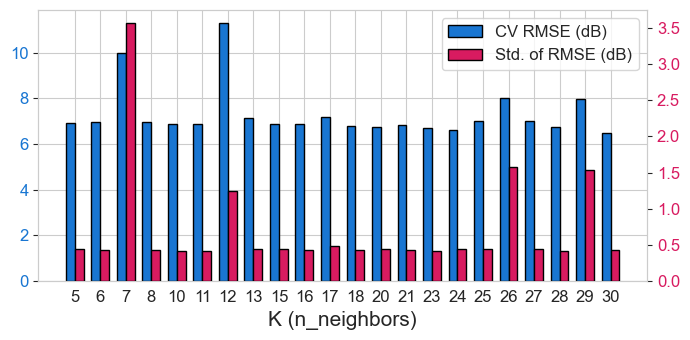

In [8]:
# Display KNN CV RMSE and RMSE variability across all searched K values

tick_fontsize = 12
axis_labelsize = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

cv_knn_df = cv_knn_df.sort_values("K").reset_index(drop=True)
x = np.arange(len(cv_knn_df["K"]))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(
    x - bar_width / 2,
    cv_knn_df["best_cv_rmse"],
    bar_width,
    color="#1976d2",
    label="RMSE",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
ax1.set_xlabel("K (n_neighbors)", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels(cv_knn_df["K"].astype(int), fontsize=tick_fontsize, rotation=0)
ax1.tick_params(axis="y", labelcolor="#1976d2", labelsize=tick_fontsize)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + bar_width / 2,
    cv_knn_df["std_cv_rmse"],
    bar_width,
    color="#d81b60",
    label="Std. of RMSE",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
ax2.tick_params(axis="y", labelcolor="#d81b60", labelsize=tick_fontsize)
ax2.grid(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#1976d2", edgecolor="black", label="CV RMSE (dB)"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#d81b60", edgecolor="black", label="Std. of RMSE (dB)"),
]
ax1.legend(handles=handles, loc="upper right", fontsize=legend_fontsize)

fig.tight_layout()
plt.show()


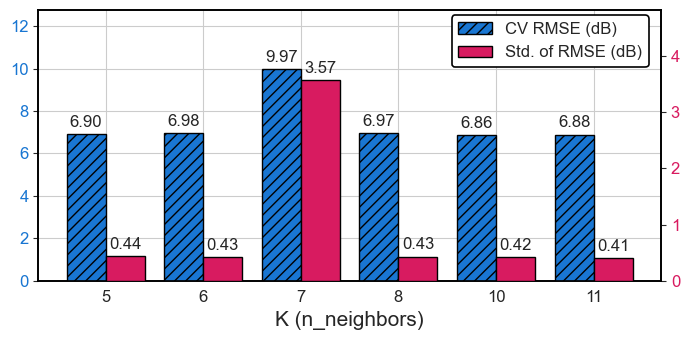

Saved figure: Figures/KNN_bestRMSE_STD_perK_first6.png


In [9]:
# Plot and save the focused KNN CV RMSE figure for the first 6 K values

tick_fontsize   = 12
axis_labelsize  = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

cv_knn_df_plot = cv_knn_df.copy()
cv_knn_df_plot["K"] = pd.to_numeric(cv_knn_df_plot["K"], errors="coerce")
cv_knn_df_plot = cv_knn_df_plot.sort_values("K").reset_index(drop=True)
cv_knn_df_plot = cv_knn_df_plot.iloc[:6].copy()

if cv_knn_df_plot.empty:
    raise ValueError("No KNN CV rows available for plotting.")

x = np.arange(len(cv_knn_df_plot["K"]))
bar_width = 0.40

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(
    x - bar_width / 2,
    cv_knn_df_plot["best_cv_rmse"].astype(float),
    bar_width,
    color="#1976d2",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
for bar in bars1:
    bar.set_hatch("///")

ax1.set_xlabel("K (n_neighbors)", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels(cv_knn_df_plot["K"].astype(int), fontsize=tick_fontsize, rotation=0)
ax1.tick_params(axis="y", labelcolor="#1976d2", labelsize=tick_fontsize)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + bar_width / 2,
    cv_knn_df_plot["std_cv_rmse"].astype(float),
    bar_width,
    color="#d81b60",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
ax2.tick_params(axis="y", labelcolor="#d81b60", labelsize=tick_fontsize)
ax2.grid(False)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

ax1.bar_label(bars1, fmt="%.2f", padding=3, fontsize=tick_fontsize)
ax2.bar_label(bars2, fmt="%.2f", padding=3, fontsize=tick_fontsize)

ax1.set_ylim(0, float(cv_knn_df_plot["best_cv_rmse"].max()) * 1.28)
ax2.set_ylim(0, float(cv_knn_df_plot["std_cv_rmse"].max()) * 1.35)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#1976d2", edgecolor="black", hatch="///", label="CV RMSE (dB)"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#d81b60", edgecolor="black", label="Std. of RMSE (dB)"),
]
leg = ax1.legend(
    handles=handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    borderaxespad=0.0,
    fontsize=legend_fontsize,
    frameon=True,
    framealpha=1.0,
)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.2)
leg.get_frame().set_facecolor("white")

fig.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "KNN_bestRMSE_STD_perK_first6.png")
plt.savefig(fig_path, dpi=2000, bbox_inches="tight", pad_inches=0.03)
plt.show()
print(f"Saved figure: {fig_path}")


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Plot: Best CV R² & its STD vs K
</p>

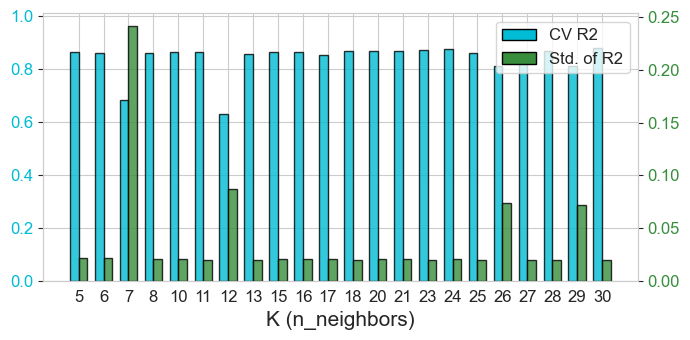

In [10]:
# Display KNN CV R2 and R2 variability across searched K values

tick_fontsize = 12
axis_labelsize = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

cv_knn_df = cv_knn_df.sort_values("K").reset_index(drop=True)
x = np.arange(len(cv_knn_df["K"]))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(
    x - bar_width / 2,
    cv_knn_df["best_cv_r2"],
    bar_width,
    color="#00bcd4",
    edgecolor="black",
    linewidth=1,
    alpha=0.8,
    label="R2",
)
ax1.set_xlabel("K (n_neighbors)", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels(cv_knn_df["K"].astype(int), fontsize=tick_fontsize)
ax1.tick_params(axis="y", labelcolor="#00bcd4", labelsize=tick_fontsize)
ax1.tick_params(axis="x", labelsize=tick_fontsize)
ax1.set_ylim(0, 1.01)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + bar_width / 2,
    cv_knn_df["std_cv_r2"],
    bar_width,
    color="#388e3c",
    edgecolor="black",
    linewidth=1,
    alpha=0.8,
    label="Std. of R2",
)
ax2.tick_params(axis="y", labelcolor="#388e3c", labelsize=tick_fontsize)
ax2.grid(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#00bcd4", edgecolor="black", label="CV R2"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#388e3c", edgecolor="black", label="Std. of R2"),
]
ax1.legend(handles=handles, loc="upper right", fontsize=legend_fontsize)

fig.tight_layout()
plt.show()


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Train best KNN on full train set, evaluate on test, and save model
</p>

In [11]:
# Train final model, evaluate on held-out test, and save model/residual artifacts

best_knn_model = create_knn_pipeline()
best_knn_model.set_params(**best_knn_params)
best_knn_model.fit(X_train_df, y_train)

print("Best KNN Parameters Used:", best_knn_params)
print("\nFinal KNN model trained on the full training split.")

# Train/test predictions
y_train_pred = best_knn_model.predict(X_train_df)
y_test_pred = best_knn_model.predict(X_test_df)

# OOF predictions using the selected best parameters
# This avoids reporting kNN's optimistic self-neighbor training error as the main train diagnostic.
y_pred_oof = np.full(len(y_train), np.nan, dtype=float)
cv_fold_ids = sorted(np.unique(fold_assignments[fold_assignments != -1]))

if not cv_fold_ids:
    raise ValueError("No validation fold labels found for OOF residual generation.")

for fold_num in cv_fold_ids:
    tr_idx = np.where(fold_assignments != fold_num)[0]
    val_idx = np.where(fold_assignments == fold_num)[0]

    fold_model = create_knn_pipeline()
    fold_model.set_params(**best_knn_params)
    fold_model.fit(X_train_df.iloc[tr_idx], y_train[tr_idx])
    y_pred_oof[val_idx] = fold_model.predict(X_train_df.iloc[val_idx])

mask = ~np.isnan(y_pred_oof)
PL_pred_oof = y_pred_oof[mask]
resid_oof = y_train[mask] - PL_pred_oof

if mask.sum() != len(y_train):
    print(f"OOF residuals generated for {mask.sum()} of {len(y_train)} training rows.")

# Metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
oof_mse = mean_squared_error(y_train[mask], PL_pred_oof)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
oof_rmse = np.sqrt(oof_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
oof_r2 = r2_score(y_train[mask], PL_pred_oof)

test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_median_ae = median_absolute_error(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    "Metric": [
        "Train MSE (apparent)", "Train RMSE (apparent)", "Train R2 (apparent)",
        "OOF MSE", "OOF RMSE", "OOF R2",
        "Test MSE", "Test RMSE", "Test R2",
        "Test MAPE (%)", "Test Median AE",
    ],
    "Value": [
        train_mse, train_rmse, train_r2,
        oof_mse, oof_rmse, oof_r2,
        test_mse, test_rmse, test_r2,
        test_mape * 100, test_median_ae,
    ],
})

print("\nModel Evaluation Metrics:")
display(metrics_df)

# Save final model
with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_knn_model, f)
print(f"\nTrained KNN model saved to: {MODEL_PATH}")

# TEST residuals
PL_pred_test = y_test_pred
resid_test = y_test - PL_pred_test

knn_test_df = pd.DataFrame({
    "model":       "KNN",
    "split":       "test",
    "row_id":      np.arange(len(df_test), dtype=int),
    "time":        df_test.get("time", pd.Series(index=df_test.index, dtype=float)).values,
    "device_id":   df_test["device_id"].values,
    "distance":    df_test["distance"].values,
    "frequency":   df_test["frequency"].values,
    "c_walls":     df_test["c_walls"].values,
    "w_walls":     df_test["w_walls"].values,
    "co2":         df_test["co2"].values,
    "humidity":    df_test["humidity"].values,
    "pm25":        df_test["pm25"].values,
    "pressure":    df_test["pressure"].values,
    "temperature": df_test["temperature"].values,
    "snr":         df_test["snr"].values,
    "PL_true":     y_test,
    "PL_pred":     PL_pred_test,
    "resid_db":    resid_test,
})

test_residual_path = os.path.join(RESIDUALS_DIR, "residuals_KNN_test.csv")
knn_test_df.to_csv(test_residual_path, index=False)
print(f"[TEST] Saved KNN test residuals: {test_residual_path}")

# OOF residuals
knn_oof_df = pd.DataFrame({
    "model":       "KNN",
    "split":       "oof",
    "row_id":      np.arange(len(df_train), dtype=int)[mask],
    "fold":        fold_assignments.astype(int)[mask],
    "time":        df_train.get("time", pd.Series(index=df_train.index, dtype=float)).values[mask],
    "device_id":   df_train["device_id"].values[mask],
    "distance":    df_train["distance"].values[mask],
    "frequency":   df_train["frequency"].values[mask],
    "c_walls":     df_train["c_walls"].values[mask],
    "w_walls":     df_train["w_walls"].values[mask],
    "co2":         df_train["co2"].values[mask],
    "humidity":    df_train["humidity"].values[mask],
    "pm25":        df_train["pm25"].values[mask],
    "pressure":    df_train["pressure"].values[mask],
    "temperature": df_train["temperature"].values[mask],
    "snr":         df_train["snr"].values[mask],
    "PL_true":     y_train[mask],
    "PL_pred":     PL_pred_oof,
    "resid_db":    resid_oof,
})

oof_residual_path = os.path.join(RESIDUALS_DIR, "residuals_KNN_oof.csv")
knn_oof_df.to_csv(oof_residual_path, index=False)
print(f"[OOF] Saved KNN OOF residuals: {oof_residual_path}")


Best KNN Parameters Used: OrderedDict({'knn__leaf_size': 80, 'knn__metric': 'minkowski', 'knn__n_neighbors': 30, 'knn__p': 1.0, 'knn__weights': 'uniform', 'pca': 'passthrough', 'power': PowerTransformer(standardize=False), 'scaler': StandardScaler(), 'whitener': 'passthrough'})

Final KNN model trained on the full training split.

Model Evaluation Metrics:


,Metric,Value
0,Train MSE (apparent),9.177669
1,Train RMSE (apparent),3.029467
2,Train R2 (apparent),0.974077
3,OOF MSE,41.720262
4,OOF RMSE,6.459122
5,OOF R2,0.882156
6,Test MSE,25.611347
7,Test RMSE,5.060765
8,Test R2,0.927755
9,Test MAPE (%),4.503688



Trained KNN model saved to: Models/knn_final_model.pkl
[TEST] Saved KNN test residuals: Residuals/residuals_KNN_test.csv
[OOF] Saved KNN OOF residuals: Residuals/residuals_KNN_oof.csv


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Learning curve
</p>

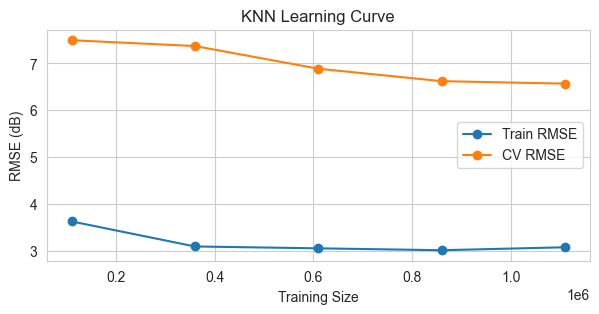

In [12]:
# KNN learning curve with the predefined time-aware folds

figsize = (7, 3)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_knn_model,
    X=X_train_df,
    y=y_train,
    cv=PredefinedSplit(fold_assignments),
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="neg_root_mean_squared_error",
)

train_rmse_curve = -train_scores.mean(axis=1)
val_rmse_curve = -test_scores.mean(axis=1)

plt.figure(figsize=figsize)
plt.plot(train_sizes, train_rmse_curve, "o-", label="Train RMSE")
plt.plot(train_sizes, val_rmse_curve, "o-", label="CV RMSE")
plt.xlabel("Training Size")
plt.ylabel("RMSE (dB)")
plt.title("KNN Learning Curve")
plt.legend()
plt.show()


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Residuals 
</p>

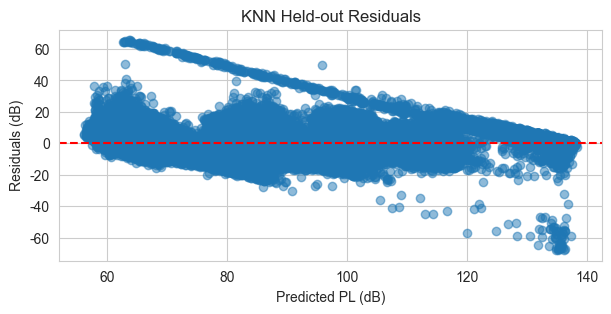

In [13]:
# Held-out residual plot

plt.figure(figsize=(7, 3))
plt.scatter(y_test_pred, resid_test, alpha=0.5)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predicted PL (dB)")
plt.ylabel("Residuals (dB)")
plt.title("KNN Held-out Residuals")
plt.show()


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Physics consistency: PL vs log10(distance)
</p>

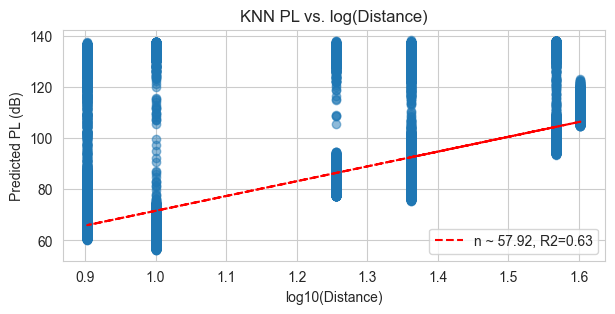

In [14]:
# Physics consistency: predicted PL vs. log10(distance)

dist = df_test["distance"].to_numpy()
log_dist = np.log10(dist + 1e-6)
slope, intercept, r_value, _, _ = linregress(log_dist, y_test_pred)

plt.figure(figsize=(7, 3))
plt.scatter(log_dist, y_test_pred, alpha=0.5)
plt.plot(log_dist, intercept + slope * log_dist, "r--", label=f"n ~ {slope:.2f}, R2={r_value**2:.2f}")
plt.xlabel("log10(Distance)")
plt.ylabel("Predicted PL (dB)")
plt.title("KNN PL vs. log(Distance)")
plt.legend()
plt.show()


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Predicted vs Real
</p>

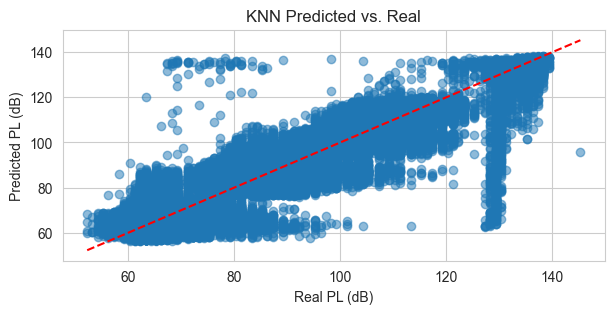

In [15]:
# Predicted vs. real PL on the held-out test split

plt.figure(figsize=(7, 3))
plt.scatter(y_test, y_test_pred, alpha=0.5)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Real PL (dB)")
plt.ylabel("Predicted PL (dB)")
plt.title("KNN Predicted vs. Real")
plt.show()
